In [131]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

### **Load data**

In [132]:
rfm_df = pd.read_csv(
    "../data/processed/rfm_dataset.csv"
)

rfm_df.head()

,Customer ID,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts
0,12346.0,326,12,77556.46,6463.038333,27
1,12347.0,2,8,4921.53,615.191250,126
2,12348.0,75,5,2019.40,403.880000,25
3,12349.0,19,4,4428.69,1107.172500,138
4,12350.0,310,1,334.40,334.400000,17


In [133]:
rfm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        5878 non-null   float64
 1   Recency            5878 non-null   int64  
 2   Frequency          5878 non-null   int64  
 3   Monetary           5878 non-null   float64
 4   AverageOrderValue  5878 non-null   float64
 5   UniqueProducts     5878 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 275.7 KB


In [134]:
rfm_df.describe()

,Customer ID,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts
count,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,2955.904095,385.180841,81.989112
std,1715.572666,209.338707,13.009406,14440.852688,1214.286459,116.484552
min,12346.000000,1.000000,1.000000,2.950000,2.950000,1.000000
25%,13833.250000,26.000000,1.000000,342.280000,176.682500,19.000000
50%,15314.500000,96.000000,3.000000,867.740000,279.242679,45.000000
75%,16797.750000,380.000000,7.000000,2248.305000,414.902458,103.000000
max,18287.000000,739.000000,398.000000,580987.040000,84236.250000,2550.000000


In [135]:
rfm_df.isnull().sum()

Customer ID          0
Recency              0
Frequency            0
Monetary             0
AverageOrderValue    0
UniqueProducts       0
dtype: int64

In [136]:
cluster_features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "UniqueProducts"
]

X = rfm_df[cluster_features].copy()
X_log = np.log1p(X)
X.head()


,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts
0,326,12,77556.46,6463.038333,27
1,2,8,4921.53,615.191250,126
2,75,5,2019.40,403.880000,25
3,19,4,4428.69,1107.172500,138
4,310,1,334.40,334.400000,17


### **Scale RFM features**

In [137]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)


### **Number of clusters**

**elbow method**


In [138]:
inertia_values = []
k_values = range(2,11)

for i in k_values:
    kmeans = KMeans(n_clusters=i, init='k-means++',random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)



10 different initial cluster starting configurations

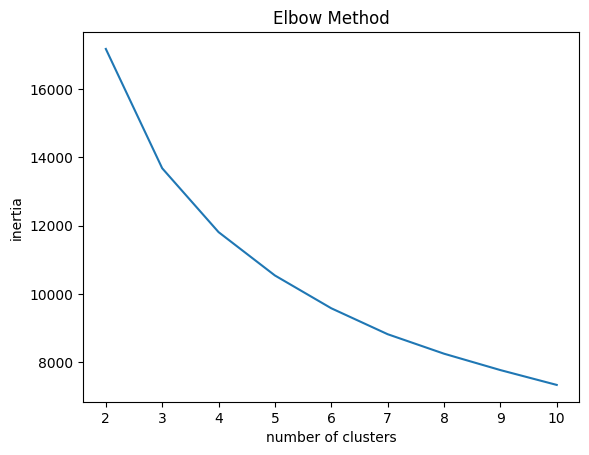

In [139]:
plt.plot(range(2,11), inertia_values)
plt.title("Elbow Method")
plt.xlabel("number of clusters")
plt.ylabel("inertia")
plt.show()

### **Silhouette Score**

In [140]:
silhouette_scores = []

for i in k_values:
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    silhouette_scores.append(score)

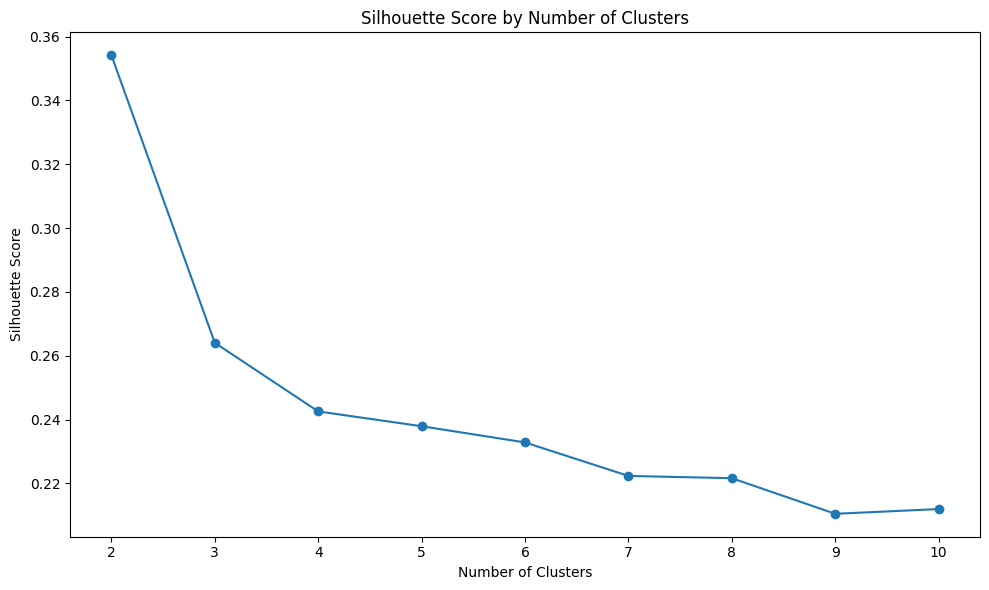

In [141]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.xticks(k_values)
plt.tight_layout()
plt.show()

In [142]:
for k, score in zip(
    k_values,
    silhouette_scores
):
    print(
        f"K={k}: Silhouette Score={score:.4f}"
    )

K=2: Silhouette Score=0.3541
K=3: Silhouette Score=0.2641
K=4: Silhouette Score=0.2426
K=5: Silhouette Score=0.2379
K=6: Silhouette Score=0.2329
K=7: Silhouette Score=0.2224
K=8: Silhouette Score=0.2216
K=9: Silhouette Score=0.2105
K=10: Silhouette Score=0.2120


In [143]:
cluster_results = {}

for k in [2, 3, 4, 5]:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    cluster_results[k] = {
        "model": kmeans,
        "labels": labels
    }

    print(f"\nK={k}")
    print(
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )


K=2
0    3295
1    2583
Name: count, dtype: int64

K=3
0    2558
1    1505
2    1815
Name: count, dtype: int64

K=4
0    1594
1    1418
2    1199
3    1667
Name: count, dtype: int64

K=5
0     869
1    1258
2    1641
3    1043
4    1067
Name: count, dtype: int64


In [144]:
for k in [2, 3, 4, 5]:

    labels = cluster_results[k]["labels"]

    temp_df = rfm_df[cluster_features].copy()
    temp_df["Cluster"] = labels

    summary = (
        temp_df
        .groupby("Cluster")[cluster_features]
        .mean()
        .round(2)
    )

    print(f"\n========== K={k} ==========")
    print(summary)


========== K=2 ==========
         Recency  Frequency  Monetary  AverageOrderValue  UniqueProducts
Cluster                                                                 
0         301.67       2.04    497.65             270.49           28.27
1          73.34      11.71   6091.77             531.49          150.52

========== K=3 ==========
         Recency  Frequency  Monetary  AverageOrderValue  UniqueProducts
Cluster                                                                 
0         187.60       3.47   1236.80             437.75           60.41
1          39.67      16.76   9138.10             546.48          198.03
2         354.73       1.58    252.47             177.35           16.18

========== K=4 ==========
         Recency  Frequency  Monetary  AverageOrderValue  UniqueProducts
Cluster                                                                 
0          55.95       5.05   1277.42             274.64           76.87
1         345.61       1.58    212.27      

In [145]:
k = 5

labels = cluster_results[k]["labels"]

temp_df = rfm_df[cluster_features].copy()
temp_df["Cluster"] = labels

summary = (
    temp_df
    .groupby("Cluster")
    .agg(
        Customers=("Recency", "count"),
        Recency=("Recency", "mean"),
        Frequency=("Frequency", "mean"),
        Monetary=("Monetary", "mean"),
        AverageOrderValue=("AverageOrderValue", "mean"),
        UniqueProducts=("UniqueProducts", "mean")
    )
    .round(2)
)

print(summary)

         Customers  Recency  Frequency  Monetary  AverageOrderValue  \
Cluster                                                               
0              869   344.63       1.51    157.93             113.44   
1             1258    37.78       4.64   1062.54             248.43   
2             1641   354.64       1.88    499.68             299.67   
3             1043    29.03      20.85  11408.56             473.41   
4             1067   210.09       4.68   2981.99             812.99   

         UniqueProducts  
Cluster                  
0                  9.36  
1                 66.63  
2                 30.71  
3                231.40  
4                 92.07  


In [146]:
k = 5

labels = cluster_results[k]["labels"]

clustered_rfm = rfm_df[cluster_features].copy()
clustered_rfm["Cluster"] = labels

median_summary = (
    clustered_rfm
    .groupby("Cluster")
    .agg(
        Customers=("Recency", "count"),
        Recency=("Recency", "median"),
        Frequency=("Frequency", "median"),
        Monetary=("Monetary", "median"),
        AverageOrderValue=("AverageOrderValue", "median"),
        UniqueProducts=("UniqueProducts", "median")
    )
    .round(2)
)

print(median_summary)

         Customers  Recency  Frequency  Monetary  AverageOrderValue  \
Cluster                                                               
0              869    376.0        1.0    136.31             110.92   
1             1258     24.0        4.0    951.48             228.19   
2             1641    379.0        1.0    426.60             272.42   
3             1043     16.0       14.0   5381.08             371.66   
4             1067    149.0        4.0   1962.30             492.16   

         UniqueProducts  
Cluster                  
0                   8.0  
1                  53.0  
2                  26.0  
3                 186.0  
4                  76.0  


In [147]:
cluster_sizes = (
    clustered_rfm["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_percentages = (
    cluster_sizes / len(clustered_rfm) * 100
).round(2)

print(cluster_percentages)

Cluster
0    14.78
1    21.40
2    27.92
3    17.74
4    18.15
Name: count, dtype: float64


In [148]:
optimal_k = 5

kmeans_model = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm_df["Cluster"] = (
    kmeans_model.fit_predict(X_scaled)
    )

In [149]:
rfm_df.head()

,Customer ID,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts,Cluster
0,12346.0,326,12,77556.46,6463.038333,27,4
1,12347.0,2,8,4921.53,615.191250,126,3
2,12348.0,75,5,2019.40,403.880000,25,4
3,12349.0,19,4,4428.69,1107.172500,138,4
4,12350.0,310,1,334.40,334.400000,17,2


In [150]:
cluster_counts = (
    rfm_df["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

Cluster
0     869
1    1258
2    1641
3    1043
4    1067
Name: count, dtype: int64

In [151]:
cluster_percentages = (
    cluster_counts / len(rfm_df) * 100
).round(2)

print(cluster_percentages)

Cluster
0    14.78
1    21.40
2    27.92
3    17.74
4    18.15
Name: count, dtype: float64


In [152]:
cluster_profile = (
    rfm_df
    .groupby("Cluster")
    .agg(
        Customers=("Customer ID", "count"),
        Recency=("Recency", "median"),
        Frequency=("Frequency", "median"),
        Monetary=("Monetary", "median"),
        AverageOrderValue=("AverageOrderValue", "median"),
        UniqueProducts=("UniqueProducts", "median")
    )
    .round(2)
)

print(cluster_profile)

         Customers  Recency  Frequency  Monetary  AverageOrderValue  \
Cluster                                                               
0              869    376.0        1.0    136.31             110.92   
1             1258     24.0        4.0    951.48             228.19   
2             1641    379.0        1.0    426.60             272.42   
3             1043     16.0       14.0   5381.08             371.66   
4             1067    149.0        4.0   1962.30             492.16   

         UniqueProducts  
Cluster                  
0                   8.0  
1                  53.0  
2                  26.0  
3                 186.0  
4                  76.0  


In [153]:
segment_names = {
    0: "Low-Value Inactive",
    1: "Recent Regular",
    2: "Inactive Occasional",
    3: "High-Value Loyal",
    4: "High-Spending Less Recent"
}

rfm_df["Segment"] = rfm_df["Cluster"].map(segment_names)

In [154]:
rfm_df[
    ["Customer ID", "Cluster", "Segment"]
].head(20)

,Customer ID,Cluster,Segment
0,12346.0,4,High-Spending Less Recent
1,12347.0,3,High-Value Loyal
2,12348.0,4,High-Spending Less Recent
3,12349.0,4,High-Spending Less Recent
4,12350.0,2,Inactive Occasional
5,12351.0,2,Inactive Occasional
6,12352.0,3,High-Value Loyal
7,12353.0,2,Inactive Occasional
8,12354.0,4,High-Spending Less Recent
9,12355.0,2,Inactive Occasional


In [155]:
customer_segments = rfm_df[
    [
        "Customer ID",
        "Recency",
        "Frequency",
        "Monetary",
        "AverageOrderValue",
        "UniqueProducts",
        "Cluster",
        "Segment"
    ]
].copy()

In [156]:
customer_segments.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

In [157]:
customer_segments.head()

,Customer ID,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts,Cluster,Segment
0,12346.0,326,12,77556.46,6463.038333,27,4,High-Spending Less Recent
1,12347.0,2,8,4921.53,615.191250,126,3,High-Value Loyal
2,12348.0,75,5,2019.40,403.880000,25,4,High-Spending Less Recent
3,12349.0,19,4,4428.69,1107.172500,138,4,High-Spending Less Recent
4,12350.0,310,1,334.40,334.400000,17,2,Inactive Occasional


In [158]:
customer_segments.shape

(5878, 8)

In [159]:
segment_summary = (
    customer_segments
    .groupby(["Cluster", "Segment"])
    .agg(
        Customers=("Customer ID", "count"),
        Recency=("Recency", "median"),
        Frequency=("Frequency", "median"),
        Monetary=("Monetary", "median"),
        AverageOrderValue=("AverageOrderValue", "median"),
        UniqueProducts=("UniqueProducts", "median")
    )
    .reset_index()
    .round(2)
)

segment_summary

,Cluster,Segment,Customers,Recency,Frequency,Monetary,AverageOrderValue,UniqueProducts
0,0,Low-Value Inactive,869,376.0,1.0,136.31,110.92,8.0
1,1,Recent Regular,1258,24.0,4.0,951.48,228.19,53.0
2,2,Inactive Occasional,1641,379.0,1.0,426.60,272.42,26.0
3,3,High-Value Loyal,1043,16.0,14.0,5381.08,371.66,186.0
4,4,High-Spending Less Recent,1067,149.0,4.0,1962.30,492.16,76.0


In [160]:
segment_summary.to_csv(
    "../data/processed/customer_segment_summary.csv",
    index=False
)

In [161]:

final_silhouette = silhouette_score(
    X_scaled,
    rfm_df["Cluster"]
)

print(f"Final Silhouette Score: {final_silhouette:.4f}")

print("Final Customer Segmentation Model")
print("----------------------------------")
print(f"Number of Clusters: {optimal_k}")
print(f"Number of Customers: {len(rfm_df)}")
print(f"Silhouette Score: {final_silhouette:.4f}")

print("\nCluster Distribution:")
print(cluster_counts)

print("\nSegment Distribution:")
print(
    rfm_df["Segment"]
    .value_counts()
)

Final Silhouette Score: 0.2379
Final Customer Segmentation Model
----------------------------------
Number of Clusters: 5
Number of Customers: 5878
Silhouette Score: 0.2379

Cluster Distribution:
Cluster
0     869
1    1258
2    1641
3    1043
4    1067
Name: count, dtype: int64

Segment Distribution:
Segment
Inactive Occasional          1641
Recent Regular               1258
High-Spending Less Recent    1067
High-Value Loyal             1043
Low-Value Inactive            869
Name: count, dtype: int64


In [162]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = rfm_df["Cluster"].values

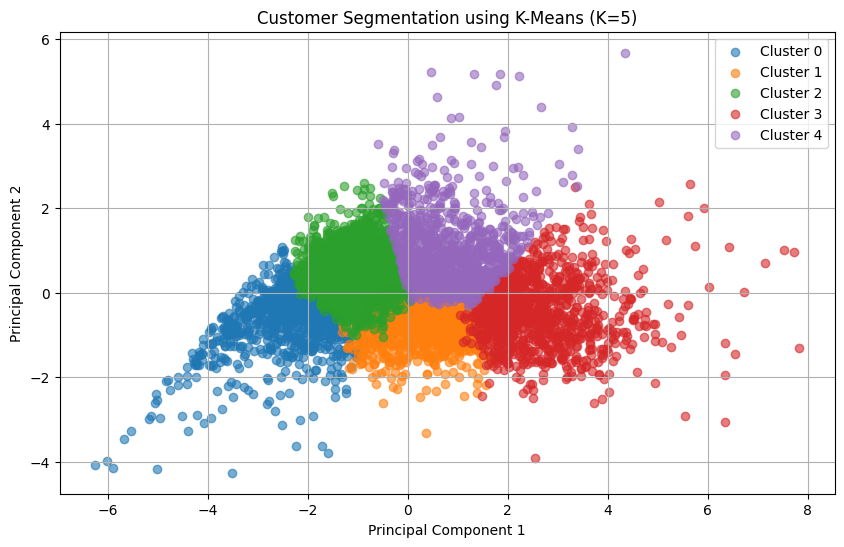

In [163]:
plt.figure(figsize=(10, 6))

for cluster in sorted(pca_df["Cluster"].unique()):

    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means (K=5)")
plt.legend()
plt.grid(True)
plt.show()

### **Customer distribution**

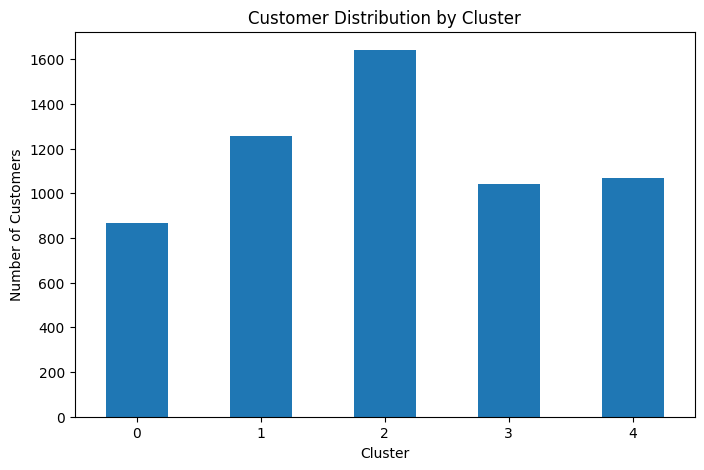

In [164]:
cluster_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Cluster")
plt.xticks(rotation=0)
plt.show()

### **Median Monetary**

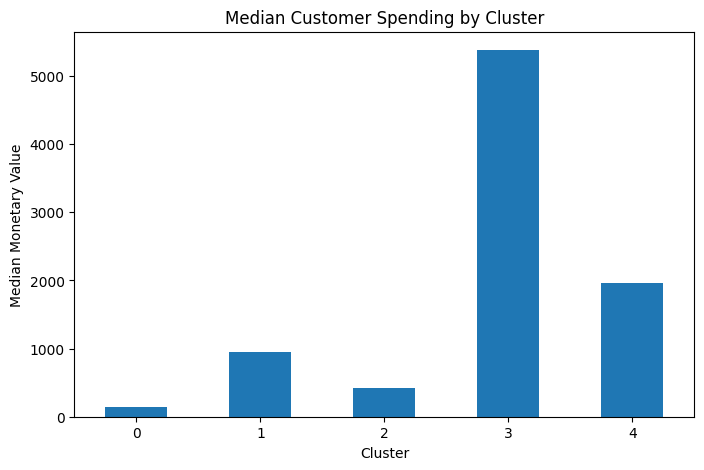

In [165]:
cluster_profile["Monetary"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Cluster")
plt.ylabel("Median Monetary Value")
plt.title("Median Customer Spending by Cluster")
plt.xticks(rotation=0)
plt.show()

### **Median Frequency**

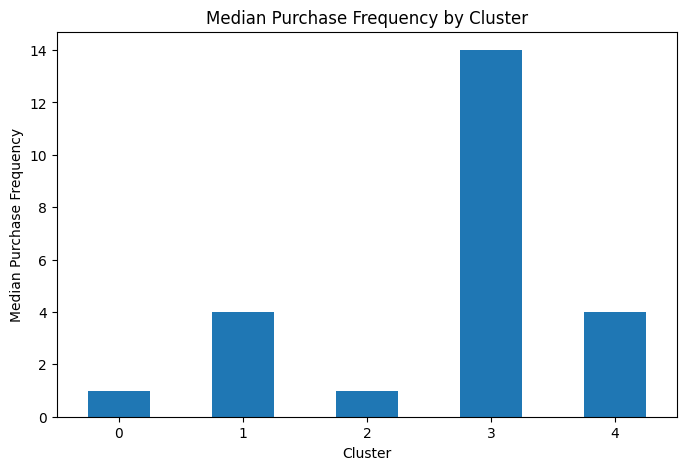

In [166]:
cluster_profile["Frequency"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Cluster")
plt.ylabel("Median Purchase Frequency")
plt.title("Median Purchase Frequency by Cluster")
plt.xticks(rotation=0)
plt.show()

### **Median Recency**

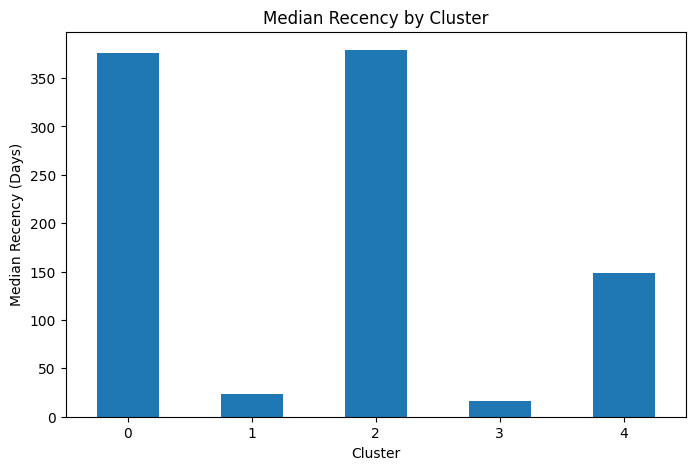

In [167]:
cluster_profile["Recency"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Cluster")
plt.ylabel("Median Recency (Days)")
plt.title("Median Recency by Cluster")
plt.xticks(rotation=0)
plt.show()

In [168]:
joblib.dump(
    kmeans_model,
    "../data/models/customer_segmentation_kmeans.pkl"
)

['../data/models/customer_segmentation_kmeans.pkl']

In [169]:
joblib.dump(
    scaler,
    "../data/models/customer_segmentation_scaler.pkl"
)

['../data/models/customer_segmentation_scaler.pkl']